<a href="https://colab.research.google.com/github/tarikathangamrajesh2025-netizen/MM26ML03-Healthcare-Triage/blob/main/MM2603_Triangle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [2]:
import pandas as pd

train = pd.read_csv('/content/train_ml03.csv')
test = pd.read_csv('/content/test_pred_ml03.csv')

print("Training data:", train.shape)
print("Test data:", test.shape)

Training data: (664, 39)
Test data: (112, 38)


In [4]:
train.head()

,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds,start_category
0,90000355,F,UNKNOWN,AMBULANCE,97.9,112.0,28.0,89.0,93.0,46.0,...,89.0,85.5,86.0,88.0,87.0,97.7,2,3,6,YELLOW
1,90000004,F,UNABLE TO OBTAIN,AMBULANCE,97.0,NaN,0.0,57.0,NaN,NaN,...,45.0,45.0,NaN,NaN,NaN,96.5,2,2,7,BLACK
2,90000021,M,HISPANIC/LATINO - CUBAN,AMBULANCE,94.1,0.0,0.0,NaN,NaN,NaN,...,24.0,24.0,NaN,NaN,NaN,96.0,3,1,6,BLACK
3,90000176,F,UNKNOWN,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,26.0,26.0,10.0,10.0,10.0,96.7,3,1,10,BLACK
4,90000200,M,WHITE,AMBULANCE,94.5,0.0,0.0,27.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,94.8,1,2,9,BLACK


In [5]:
test.head()

,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_min,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds
0,90000431,M,PATIENT DECLINED TO ANSWER,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,21.000000,42.000000,31.500000,96.200000,2,2,6
1,90000438,F,WHITE - OTHER EUROPEAN,AMBULANCE,93.5,21.0,0.0,35.0,NaN,NaN,...,16.0,26.0,21.0,55.000000,55.000000,55.000000,96.600000,3,2,4
2,90000445,F,PATIENT DECLINED TO ANSWER,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,36.0,39.0,37.5,NaN,NaN,NaN,96.600000,3,2,14
3,90000457,F,HISPANIC/LATINO - SALVADORAN,AMBULANCE,93.8,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,94.275702,1,2,11
4,90000460,F,WHITE,AMBULANCE,95.3,0.0,0.0,43.0,NaN,NaN,...,NaN,NaN,NaN,44.841077,45.819711,45.317784,96.049343,3,3,12


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            664 non-null    int64  
 1   gender                664 non-null    object 
 2   race                  664 non-null    object 
 3   arrival_transport     664 non-null    object 
 4   temperature           582 non-null    float64
 5   heartrate             584 non-null    float64
 6   resprate              602 non-null    float64
 7   o2sat                 545 non-null    float64
 8   sbp                   523 non-null    float64
 9   dbp                   522 non-null    float64
 10  bp_unobtainable       664 non-null    int64  
 11  pain_score            427 non-null    float64
 12  pain_assessable       524 non-null    float64
 13  gcs_eye               664 non-null    int64  
 14  gcs_verbal            664 non-null    int64  
 15  gcs_motor             6

In [7]:
train.describe(include='all')

,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds,start_category
count,6.640000e+02,664,664,664,582.000000,584.000000,602.000000,545.000000,523.000000,522.000000,...,581.000000,581.000000,593.000000,593.000000,593.000000,627.000000,664.000000,664.000000,664.000000,664
unique,NaN,2,12,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,M,WHITE,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YELLOW
freq,NaN,347,172,389,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,284
mean,6.795717e+07,NaN,NaN,NaN,97.700687,87.535959,18.843854,90.673394,112.336520,67.084291,...,117.650090,108.065546,88.453686,92.074876,90.302695,97.955612,3.668675,2.213855,5.868976,NaN
std,3.576408e+07,NaN,NaN,NaN,1.696752,34.615785,9.293810,12.663189,27.388743,18.511826,...,27.114958,25.096063,14.806703,13.741606,14.168029,4.636126,2.579975,1.186673,7.439206,NaN
min,1.000172e+07,NaN,NaN,NaN,82.000000,0.000000,0.000000,15.000000,43.000000,20.000000,...,19.000000,19.000000,0.000000,0.000000,0.000000,35.300000,0.000000,1.000000,0.000000,NaN
25%,1.003873e+07,NaN,NaN,NaN,97.500000,76.000000,16.000000,89.000000,97.500000,56.000000,...,105.000000,96.500000,88.000000,91.000000,89.500000,98.000000,2.000000,1.000000,2.000000,NaN
50%,9.000016e+07,NaN,NaN,NaN,98.000000,91.000000,18.000000,95.000000,111.000000,69.000000,...,117.000000,110.200000,93.000000,96.000000,95.000000,98.600000,3.000000,2.000000,3.000000,NaN
75%,9.000036e+07,NaN,NaN,NaN,98.500000,106.000000,23.000000,98.000000,124.000000,80.000000,...,130.000000,120.500000,96.000000,99.000000,97.666667,99.000000,5.000000,3.000000,7.000000,NaN


In [8]:
for i, col in enumerate(train.columns):
    print(i, ":", col)

0 : subject_id
1 : gender
2 : race
3 : arrival_transport
4 : temperature
5 : heartrate
6 : resprate
7 : o2sat
8 : sbp
9 : dbp
10 : bp_unobtainable
11 : pain_score
12 : pain_assessable
13 : gcs_eye
14 : gcs_verbal
15 : gcs_motor
16 : gcs_total
17 : avpu
18 : avpu_ordinal
19 : follows_commands
20 : consciousness_source
21 : chiefcomplaint
22 : vs_heartrate_min
23 : vs_heartrate_max
24 : vs_heartrate_mean
25 : vs_resprate_min
26 : vs_resprate_max
27 : vs_resprate_mean
28 : vs_sbp_min
29 : vs_sbp_max
30 : vs_sbp_mean
31 : vs_o2sat_min
32 : vs_o2sat_max
33 : vs_o2sat_mean
34 : vs_temperature_max
35 : n_vitalsign_readings
36 : n_diagnoses
37 : n_home_meds
38 : start_category


In [9]:
print("TRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

TRAIN COLUMNS:
['subject_id', 'gender', 'race', 'arrival_transport', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu', 'avpu_ordinal', 'follows_commands', 'consciousness_source', 'chiefcomplaint', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max', 'n_vitalsign_readings', 'n_diagnoses', 'n_home_meds', 'start_category']

TEST COLUMNS:
['subject_id', 'gender', 'race', 'arrival_transport', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu', 'avpu_ordinal', 'follows_commands', 'consciousness_source', 'chiefcomplaint', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate

In [10]:
print(train['start_category'].value_counts())

start_category
YELLOW    284
GREEN     176
RED       135
BLACK      69
Name: count, dtype: int64


In [11]:
missing = train.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

pain_score            237
dbp                   142
sbp                   141
pain_assessable       140
o2sat                 119
vs_sbp_max             83
vs_sbp_mean            83
vs_sbp_min             83
temperature            82
heartrate              80
vs_o2sat_max           71
vs_o2sat_min           71
vs_o2sat_mean          71
resprate               62
vs_temperature_max     37
vs_heartrate_min       31
vs_heartrate_max       31
vs_heartrate_mean      31
vs_resprate_min        17
vs_resprate_max        17
vs_resprate_mean       17
dtype: int64


In [12]:
print(train.dtypes)

subject_id                int64
gender                   object
race                     object
arrival_transport        object
temperature             float64
heartrate               float64
resprate                float64
o2sat                   float64
sbp                     float64
dbp                     float64
bp_unobtainable           int64
pain_score              float64
pain_assessable         float64
gcs_eye                   int64
gcs_verbal                int64
gcs_motor                 int64
gcs_total                 int64
avpu                     object
avpu_ordinal              int64
follows_commands          int64
consciousness_source     object
chiefcomplaint           object
vs_heartrate_min        float64
vs_heartrate_max        float64
vs_heartrate_mean       float64
vs_resprate_min         float64
vs_resprate_max         float64
vs_resprate_mean        float64
vs_sbp_min              float64
vs_sbp_max              float64
vs_sbp_mean             float64
vs_o2sat

In [13]:
for i, col in enumerate(train.columns):
    print(i, ":", col)

0 : subject_id
1 : gender
2 : race
3 : arrival_transport
4 : temperature
5 : heartrate
6 : resprate
7 : o2sat
8 : sbp
9 : dbp
10 : bp_unobtainable
11 : pain_score
12 : pain_assessable
13 : gcs_eye
14 : gcs_verbal
15 : gcs_motor
16 : gcs_total
17 : avpu
18 : avpu_ordinal
19 : follows_commands
20 : consciousness_source
21 : chiefcomplaint
22 : vs_heartrate_min
23 : vs_heartrate_max
24 : vs_heartrate_mean
25 : vs_resprate_min
26 : vs_resprate_max
27 : vs_resprate_mean
28 : vs_sbp_min
29 : vs_sbp_max
30 : vs_sbp_mean
31 : vs_o2sat_min
32 : vs_o2sat_max
33 : vs_o2sat_mean
34 : vs_temperature_max
35 : n_vitalsign_readings
36 : n_diagnoses
37 : n_home_meds
38 : start_category


In [14]:
print(train['start_category'].value_counts())

start_category
YELLOW    284
GREEN     176
RED       135
BLACK      69
Name: count, dtype: int64


In [15]:
print(train['start_category'].value_counts(normalize=True) * 100)

start_category
YELLOW    42.771084
GREEN     26.506024
RED       20.331325
BLACK     10.391566
Name: proportion, dtype: float64


In [16]:
print(train.dtypes)

subject_id                int64
gender                   object
race                     object
arrival_transport        object
temperature             float64
heartrate               float64
resprate                float64
o2sat                   float64
sbp                     float64
dbp                     float64
bp_unobtainable           int64
pain_score              float64
pain_assessable         float64
gcs_eye                   int64
gcs_verbal                int64
gcs_motor                 int64
gcs_total                 int64
avpu                     object
avpu_ordinal              int64
follows_commands          int64
consciousness_source     object
chiefcomplaint           object
vs_heartrate_min        float64
vs_heartrate_max        float64
vs_heartrate_mean       float64
vs_resprate_min         float64
vs_resprate_max         float64
vs_resprate_mean        float64
vs_sbp_min              float64
vs_sbp_max              float64
vs_sbp_mean             float64
vs_o2sat

In [17]:
X = train.drop(columns=['start_category', 'subject_id'])
y = train['start_category']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (664, 37)
y shape: (664,)


In [18]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu_ordinal', 'follows_commands', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max', 'n_vitalsign_readings', 'n_diagnoses', 'n_home_meds']

Categorical features:
['gender', 'race', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']


In [19]:
missing = X.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

pain_score            237
dbp                   142
sbp                   141
pain_assessable       140
o2sat                 119
vs_sbp_max             83
vs_sbp_mean            83
vs_sbp_min             83
temperature            82
heartrate              80
vs_o2sat_max           71
vs_o2sat_min           71
vs_o2sat_mean          71
resprate               62
vs_temperature_max     37
vs_heartrate_min       31
vs_heartrate_max       31
vs_heartrate_mean      31
vs_resprate_min        17
vs_resprate_max        17
vs_resprate_mean       17
dtype: int64


In [20]:
print("\nNumber of columns with missing values:", len(missing))


Number of columns with missing values: 21


In [21]:
X = train.drop(columns=['start_category', 'subject_id'])
y = train['start_category']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (664, 37)
y shape: (664,)


In [22]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu_ordinal', 'follows_commands', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max', 'n_vitalsign_readings', 'n_diagnoses', 'n_home_meds']

Categorical features:
['gender', 'race', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']


In [23]:
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)
print("\nNumber of columns with missing values:", len(missing))

pain_score            237
dbp                   142
sbp                   141
pain_assessable       140
o2sat                 119
vs_sbp_max             83
vs_sbp_mean            83
vs_sbp_min             83
temperature            82
heartrate              80
vs_o2sat_max           71
vs_o2sat_min           71
vs_o2sat_mean          71
resprate               62
vs_temperature_max     37
vs_heartrate_min       31
vs_heartrate_max       31
vs_heartrate_mean      31
vs_resprate_min        17
vs_resprate_max        17
vs_resprate_mean       17
dtype: int64

Number of columns with missing values: 21


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 531
Validation samples: 133


In [25]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training class distribution:
start_category
YELLOW    227
GREEN     141
RED       108
BLACK      55
Name: count, dtype: int64

Validation class distribution:
start_category
YELLOW    57
GREEN     35
RED       27
BLACK     14
Name: count, dtype: int64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [28]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [32]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

In [33]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['temperature', 'heartrate',
                                                   'resprate', 'o2sat', 'sbp',
                                                   'dbp', 'bp_unobtainable',
                                                   'pain_score',
                                                   'pain_assessable', 'gcs_eye',
                                                   'gcs_verbal', 'gcs_motor',
                                                   'gcs_total', 'avpu_ordinal',
                                                   'follows_commands',
                                                   'vs_heartrate_min',
                                                   'vs_heart...
                                                   'n_vitalsign_readings',
                                                   'n_diagnoses', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'race',
                                                   'arrival_transport', 'avpu',
                                                   'consciousness_source',
                                                   'chiefcomplaint'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [34]:
y_pred = rf_pipeline.predict(X_val)

In [35]:
print(y_pred[:20])

['BLACK' 'BLACK' 'GREEN' 'GREEN' 'BLACK' 'YELLOW' 'GREEN' 'YELLOW' 'GREEN'
 'YELLOW' 'GREEN' 'BLACK' 'YELLOW' 'GREEN' 'GREEN' 'YELLOW' 'BLACK'
 'YELLOW' 'YELLOW' 'YELLOW']


In [36]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_val, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.9172932330827067

Classification Report:
              precision    recall  f1-score   support

       BLACK       0.88      1.00      0.93        14
       GREEN       1.00      0.91      0.96        35
         RED       1.00      0.70      0.83        27
      YELLOW       0.86      1.00      0.93        57

    accuracy                           0.92       133
   macro avg       0.93      0.90      0.91       133
weighted avg       0.93      0.92      0.91       133



In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

cm = confusion_matrix(y_val, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[19  6  0  2]
 [ 0 57  0  0]
 [ 0  3 32  0]
 [ 0  0  0 14]]


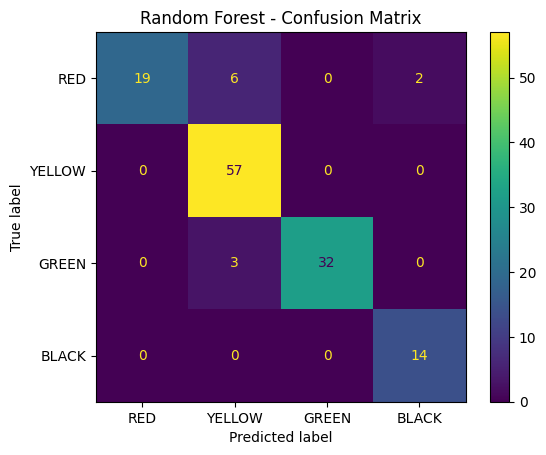

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [39]:
labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

In [40]:
cost_matrix = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0, 3, 2],    # Actual YELLOW
    [1, 1, 0, 1],    # Actual GREEN
    [2, 2, 2, 0]     # Actual BLACK
])

In [41]:
label_to_index = {
    'RED': 0,
    'YELLOW': 1,
    'GREEN': 2,
    'BLACK': 3
}

total_cost = 0

for actual, predicted in zip(y_val, y_pred):
    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]

    total_cost += cost_matrix[actual_index, predicted_index]

print("Total misclassification cost:", total_cost)

Total misclassification cost: 43


Confusion Matrix:
[[19  6  0  2]
 [ 0 57  0  0]
 [ 0  3 32  0]
 [ 0  0  0 14]]


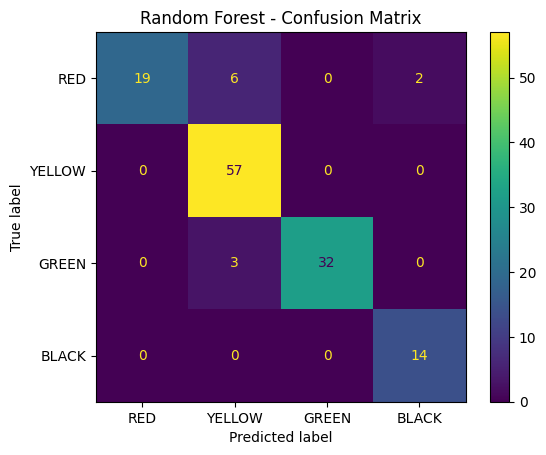

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=labels
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [43]:
# Get probability predictions
y_proba = rf_pipeline.predict_proba(X_val)

# Check the order of the classes
print("Model class order:")
print(rf_pipeline.classes_)

Model class order:
['BLACK' 'GREEN' 'RED' 'YELLOW']


In [44]:
# Current probability order from Random Forest:
# BLACK, GREEN, RED, YELLOW

# We want:
# RED, YELLOW, GREEN, BLACK

desired_order = ['RED', 'YELLOW', 'GREEN', 'BLACK']

class_indices = [
    list(rf_pipeline.classes_).index(label)
    for label in desired_order
]

y_proba_reordered = y_proba[:, class_indices]

print("New probability order:")
print(desired_order)

print("\nFirst 5 patients' probabilities:")
print(y_proba_reordered[:5])

New probability order:
['RED', 'YELLOW', 'GREEN', 'BLACK']

First 5 patients' probabilities:
[[0.10666667 0.         0.         0.89333333]
 [0.01666667 0.         0.         0.98333333]
 [0.         0.05333333 0.94666667 0.        ]
 [0.00666667 0.07       0.92333333 0.        ]
 [0.00333333 0.         0.         0.99666667]]


In [45]:
# Cost matrix
cost_matrix = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0, 3, 2],    # Actual YELLOW
    [1, 1, 0, 1],    # Actual GREEN
    [2, 2, 2, 0]     # Actual BLACK
])

# Calculate expected cost for each possible prediction
expected_cost = y_proba_reordered @ cost_matrix

# Choose the prediction with the LOWEST expected cost
cost_sensitive_indices = np.argmin(expected_cost, axis=1)

# Convert indices back to class names
labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

y_pred_cost_sensitive = np.array(labels)[cost_sensitive_indices]

print("First 10 cost-sensitive predictions:")
print(y_pred_cost_sensitive[:10])

First 10 cost-sensitive predictions:
['BLACK' 'BLACK' 'GREEN' 'GREEN' 'BLACK' 'YELLOW' 'GREEN' 'YELLOW' 'GREEN'
 'RED']


In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Original Random Forest
original_accuracy = accuracy_score(y_val, y_pred)
original_macro_f1 = f1_score(y_val, y_pred, average='macro')
original_weighted_f1 = f1_score(y_val, y_pred, average='weighted')

# Cost-sensitive Random Forest
cost_sensitive_accuracy = accuracy_score(y_val, y_pred_cost_sensitive)
cost_sensitive_macro_f1 = f1_score(
    y_val,
    y_pred_cost_sensitive,
    average='macro'
)
cost_sensitive_weighted_f1 = f1_score(
    y_val,
    y_pred_cost_sensitive,
    average='weighted'
)

# Calculate cost for cost-sensitive predictions
total_cost_sensitive = 0

for actual, predicted in zip(y_val, y_pred_cost_sensitive):
    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]
    total_cost_sensitive += cost_matrix[
        actual_index,
        predicted_index
    ]

print("===== ORIGINAL RANDOM FOREST =====")
print("Accuracy:", original_accuracy)
print("Macro-F1:", original_macro_f1)
print("Weighted-F1:", original_weighted_f1)
print("Total Cost:", total_cost)

print("\n===== COST-SENSITIVE RANDOM FOREST =====")
print("Accuracy:", cost_sensitive_accuracy)
print("Macro-F1:", cost_sensitive_macro_f1)
print("Weighted-F1:", cost_sensitive_weighted_f1)
print("Total Cost:", total_cost_sensitive)

===== ORIGINAL RANDOM FOREST =====
Accuracy: 0.9172932330827067
Macro-F1: 0.9103683596861926
Weighted-F1: 0.9145347263633989
Total Cost: 43

===== COST-SENSITIVE RANDOM FOREST =====
Accuracy: 0.8571428571428571
Macro-F1: 0.8770933889132659
Weighted-F1: 0.8519359500110522
Total Cost: 33


In [48]:
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# ORIGINAL RANDOM FOREST
# -----------------------------

original_accuracy = accuracy_score(y_val, y_pred)

original_macro_f1 = f1_score(
    y_val,
    y_pred,
    average='macro'
)

original_weighted_f1 = f1_score(
    y_val,
    y_pred,
    average='weighted'
)


# -----------------------------
# COST-SENSITIVE RANDOM FOREST
# -----------------------------

cost_sensitive_accuracy = accuracy_score(
    y_val,
    y_pred_cost_sensitive
)

cost_sensitive_macro_f1 = f1_score(
    y_val,
    y_pred_cost_sensitive,
    average='macro'
)

cost_sensitive_weighted_f1 = f1_score(
    y_val,
    y_pred_cost_sensitive,
    average='weighted'
)


# -----------------------------
# CALCULATE COST
# -----------------------------

total_cost_sensitive = 0

for actual, predicted in zip(y_val, y_pred_cost_sensitive):

    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]

    total_cost_sensitive += cost_matrix[
        actual_index,
        predicted_index
    ]


# -----------------------------
# PRINT RESULTS
# -----------------------------

print("===== ORIGINAL RANDOM FOREST =====")
print("Accuracy:", original_accuracy)
print("Macro-F1:", original_macro_f1)
print("Weighted-F1:", original_weighted_f1)
print("Total Cost:", total_cost)


print("\n===== COST-SENSITIVE RANDOM FOREST =====")
print("Accuracy:", cost_sensitive_accuracy)
print("Macro-F1:", cost_sensitive_macro_f1)
print("Weighted-F1:", cost_sensitive_weighted_f1)
print("Total Cost:", total_cost_sensitive)

===== ORIGINAL RANDOM FOREST =====
Accuracy: 0.9172932330827067
Macro-F1: 0.9103683596861926
Weighted-F1: 0.9145347263633989
Total Cost: 43

===== COST-SENSITIVE RANDOM FOREST =====
Accuracy: 0.8571428571428571
Macro-F1: 0.8770933889132659
Weighted-F1: 0.8519359500110522
Total Cost: 33


Cost-Sensitive Confusion Matrix:
[[24  3  0  0]
 [ 2 55  0  0]
 [ 0 14 21  0]
 [ 0  0  0 14]]


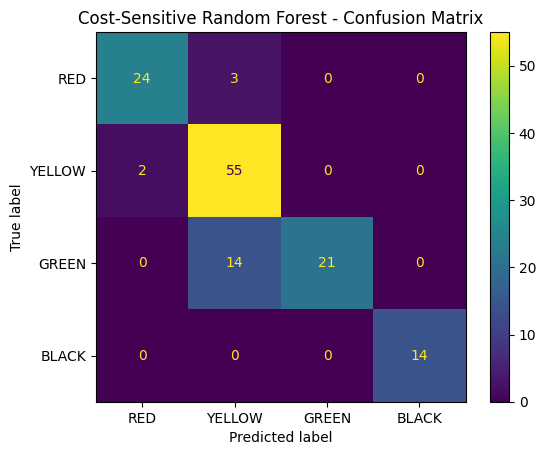

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

cm_cost = confusion_matrix(
    y_val,
    y_pred_cost_sensitive,
    labels=labels
)

print("Cost-Sensitive Confusion Matrix:")
print(cm_cost)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cost,
    display_labels=labels
)

disp.plot()
plt.title("Cost-Sensitive Random Forest - Confusion Matrix")
plt.show()

In [50]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', logreg_model)
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_val)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Make predictions
y_pred_logreg = logreg_pipeline.predict(X_val)

# Calculate metrics
logreg_accuracy = accuracy_score(y_val, y_pred_logreg)

logreg_macro_f1 = f1_score(
    y_val,
    y_pred_logreg,
    average='macro'
)

logreg_weighted_f1 = f1_score(
    y_val,
    y_pred_logreg,
    average='weighted'
)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", logreg_accuracy)
print("Macro-F1:", logreg_macro_f1)
print("Weighted-F1:", logreg_weighted_f1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg))

===== LOGISTIC REGRESSION =====
Accuracy: 0.9097744360902256
Macro-F1: 0.9214462438146649
Weighted-F1: 0.9097423044791466

Classification Report:
              precision    recall  f1-score   support

       BLACK       1.00      1.00      1.00        14
       GREEN       0.86      0.91      0.89        35
         RED       0.92      0.85      0.88        27
      YELLOW       0.91      0.91      0.91        57

    accuracy                           0.91       133
   macro avg       0.92      0.92      0.92       133
weighted avg       0.91      0.91      0.91       133



In [52]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

cm_logreg = confusion_matrix(
    y_val,
    y_pred_logreg,
    labels=labels
)

print("===== LOGISTIC REGRESSION CONFUSION MATRIX =====")
print("Rows = Actual, Columns = Predicted")
print(labels)
print(cm_logreg)

===== LOGISTIC REGRESSION CONFUSION MATRIX =====
Rows = Actual, Columns = Predicted
['RED', 'YELLOW', 'GREEN', 'BLACK']
[[23  2  2  0]
 [ 2 52  3  0]
 [ 0  3 32  0]
 [ 0  0  0 14]]


In [53]:
# Calculate total misclassification cost for Logistic Regression

cost_matrix = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0, 3, 2],    # Actual YELLOW
    [1, 1, 0, 1],     # Actual GREEN
    [2, 2, 2, 0]      # Actual BLACK
])

label_to_index = {
    'RED': 0,
    'YELLOW': 1,
    'GREEN': 2,
    'BLACK': 3
}

logreg_total_cost = 0

for actual, predicted in zip(y_val, y_pred_logreg):
    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]

    logreg_total_cost += cost_matrix[
        actual_index,
        predicted_index
    ]

print("Logistic Regression Total Misclassification Cost:",
      logreg_total_cost)

Logistic Regression Total Misclassification Cost: 46


In [54]:
from sklearn.ensemble import ExtraTreesClassifier

extra_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

extra_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', extra_model)
])

extra_pipeline.fit(X_train, y_train)

y_pred_extra = extra_pipeline.predict(X_val)

print("Extra Trees trained successfully!")

Extra Trees trained successfully!


In [55]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Make predictions
y_pred_extra = extra_pipeline.predict(X_val)

# Calculate metrics
extra_accuracy = accuracy_score(y_val, y_pred_extra)

extra_macro_f1 = f1_score(
    y_val,
    y_pred_extra,
    average='macro'
)

extra_weighted_f1 = f1_score(
    y_val,
    y_pred_extra,
    average='weighted'
)

print("===== EXTRA TREES =====")
print("Accuracy:", extra_accuracy)
print("Macro-F1:", extra_macro_f1)
print("Weighted-F1:", extra_weighted_f1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_extra))

===== EXTRA TREES =====
Accuracy: 0.9323308270676691
Macro-F1: 0.9392853934602946
Weighted-F1: 0.9313051988577264

Classification Report:
              precision    recall  f1-score   support

       BLACK       1.00      1.00      1.00        14
       GREEN       0.97      0.94      0.96        35
         RED       1.00      0.78      0.88        27
      YELLOW       0.88      0.98      0.93        57

    accuracy                           0.93       133
   macro avg       0.96      0.93      0.94       133
weighted avg       0.94      0.93      0.93       133



In [56]:
from sklearn.metrics import confusion_matrix

labels = ['RED', 'YELLOW', 'GREEN', 'BLACK']

cm_extra = confusion_matrix(
    y_val,
    y_pred_extra,
    labels=labels
)

print("===== EXTRA TREES CONFUSION MATRIX =====")
print("Rows = Actual, Columns = Predicted")
print(labels)
print(cm_extra)

===== EXTRA TREES CONFUSION MATRIX =====
Rows = Actual, Columns = Predicted
['RED', 'YELLOW', 'GREEN', 'BLACK']
[[21  6  0  0]
 [ 0 56  1  0]
 [ 0  2 33  0]
 [ 0  0  0 14]]


In [57]:
# Calculate total misclassification cost for Extra Trees

cost_matrix = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0, 3, 2],    # Actual YELLOW
    [1, 1, 0, 1],    # Actual GREEN
    [2, 2, 2, 0]     # Actual BLACK
])

label_to_index = {
    'RED': 0,
    'YELLOW': 1,
    'GREEN': 2,
    'BLACK': 3
}

extra_total_cost = 0

for actual, predicted in zip(y_val, y_pred_extra):
    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]

    extra_total_cost += cost_matrix[
        actual_index,
        predicted_index
    ]

print("Extra Trees Total Misclassification Cost:",
      extra_total_cost)

Extra Trees Total Misclassification Cost: 35


In [58]:
from sklearn.ensemble import ExtraTreesClassifier

tuned_extra_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

tuned_extra_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', tuned_extra_model)
])

tuned_extra_pipeline.fit(X_train, y_train)

y_pred_tuned_extra = tuned_extra_pipeline.predict(X_val)

print("Tuned Extra Trees trained successfully!")

Tuned Extra Trees trained successfully!


In [59]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_tuned_extra = tuned_extra_pipeline.predict(X_val)

tuned_extra_accuracy = accuracy_score(
    y_val,
    y_pred_tuned_extra
)

tuned_extra_macro_f1 = f1_score(
    y_val,
    y_pred_tuned_extra,
    average='macro'
)

tuned_extra_weighted_f1 = f1_score(
    y_val,
    y_pred_tuned_extra,
    average='weighted'
)

print("===== TUNED EXTRA TREES =====")
print("Accuracy:", tuned_extra_accuracy)
print("Macro-F1:", tuned_extra_macro_f1)
print("Weighted-F1:", tuned_extra_weighted_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_tuned_extra
    )
)

===== TUNED EXTRA TREES =====
Accuracy: 0.9323308270676691
Macro-F1: 0.9392853934602946
Weighted-F1: 0.9313051988577264

Classification Report:
              precision    recall  f1-score   support

       BLACK       1.00      1.00      1.00        14
       GREEN       0.97      0.94      0.96        35
         RED       1.00      0.78      0.88        27
      YELLOW       0.88      0.98      0.93        57

    accuracy                           0.93       133
   macro avg       0.96      0.93      0.94       133
weighted avg       0.94      0.93      0.93       133



In [60]:
tuned_extra_total_cost = 0

for actual, predicted in zip(y_val, y_pred_tuned_extra):
    actual_index = label_to_index[actual]
    predicted_index = label_to_index[predicted]

    tuned_extra_total_cost += cost_matrix[
        actual_index,
        predicted_index
    ]

print(
    "Tuned Extra Trees Total Misclassification Cost:",
    tuned_extra_total_cost
)

Tuned Extra Trees Total Misclassification Cost: 35


In [61]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    extra_pipeline,
    X,
    y,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("===== EXTRA TREES 5-FOLD CROSS-VALIDATION =====")
print("Fold Macro-F1 scores:")
print(cv_scores)

print("\nMean Macro-F1:", cv_scores.mean())
print("Std Macro-F1:", cv_scores.std())

===== EXTRA TREES 5-FOLD CROSS-VALIDATION =====
Fold Macro-F1 scores:
[0.93778894 0.90484141 0.95618784 0.93959158 0.94296521]

Mean Macro-F1: 0.9362749945418235
Std Macro-F1: 0.016986123829110765


In [62]:
# Train the final Extra Trees model using ALL training data

final_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(X, y)

print("Final model trained successfully!")
print("Training rows:", len(X))

Final model trained successfully!
Training rows: 664


In [63]:
# Train the final Extra Trees model using ALL training data

final_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(X, y)

print("Final model trained successfully!")
print("Training rows:", len(X))

Final model trained successfully!
Training rows: 664


In [64]:
# Prepare test data for prediction

X_test = test.drop(columns=['subject_id'])

print("Test data prepared successfully!")
print("Test shape:", X_test.shape)
print("Test columns:", X_test.shape[1])

Test data prepared successfully!
Test shape: (112, 37)
Test columns: 37


In [65]:
# Generate predictions for the test patients

test_predictions = final_pipeline.predict(X_test)

# Generate probabilities for each class
test_probabilities = final_pipeline.predict_proba(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(test_predictions))

print("\nModel class order:")
print(final_pipeline.classes_)

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Predictions generated successfully!
Number of predictions: 112

Model class order:
['BLACK' 'GREEN' 'RED' 'YELLOW']

First 10 predictions:
['BLACK' 'BLACK' 'BLACK' 'BLACK' 'BLACK' 'BLACK' 'BLACK' 'BLACK' 'BLACK'
 'BLACK']


In [66]:
# Required competition probability order
desired_order = ['RED', 'YELLOW', 'GREEN', 'BLACK']

# Find where each required class is in the model's probability output
class_indices = [
    list(final_pipeline.classes_).index(label)
    for label in desired_order
]

# Reorder the probability columns
test_probabilities_reordered = test_probabilities[:, class_indices]

print("Probability order for submission:")
print(desired_order)

print("\nFirst 5 probability rows:")
print(test_probabilities_reordered[:5])

Probability order for submission:
['RED', 'YELLOW', 'GREEN', 'BLACK']

First 5 probability rows:
[[0.23333333 0.         0.         0.76666667]
 [0.02       0.         0.         0.98      ]
 [0.10666667 0.         0.         0.89333333]
 [0.02666667 0.         0.00333333 0.97      ]
 [0.04666667 0.         0.         0.95333333]]


In [67]:
import pandas as pd

submission = pd.DataFrame({
    'Patient ID': test['subject_id'],
    'Predicted Triage': test_predictions,
    'RED Probability': test_probabilities_reordered[:, 0],
    'YELLOW Probability': test_probabilities_reordered[:, 1],
    'GREEN Probability': test_probabilities_reordered[:, 2],
    'BLACK Probability': test_probabilities_reordered[:, 3]
})

print("Submission created!")
print("Shape:", submission.shape)

print("\nFirst 5 rows:")
display(submission.head())

Submission created!
Shape: (112, 6)

First 5 rows:


,Patient ID,Predicted Triage,RED Probability,YELLOW Probability,GREEN Probability,BLACK Probability
0,90000431,BLACK,0.233333,0.0,0.000000,0.766667
1,90000438,BLACK,0.020000,0.0,0.000000,0.980000
2,90000445,BLACK,0.106667,0.0,0.000000,0.893333
3,90000457,BLACK,0.026667,0.0,0.003333,0.970000
4,90000460,BLACK,0.046667,0.0,0.000000,0.953333


In [69]:
# Save the submission CSV

team_id = "MM2650"

filename = f"{team_id}_MM26ML03.csv"

submission.to_csv(
    filename,
    index=False
)

print("Submission file created:")
print(filename)

Submission file created:
MM2650_MM26ML03.csv


In [71]:
team_id = "MM2650"

filename = f"{team_id}_MM26ML03.csv"

submission.to_csv(
    filename,
    index=False
)

print("Submission file created:")
print(filename)

Submission file created:
MM2650_MM26ML03.csv


In [72]:
# Final submission check

check = pd.read_csv("MM2650_MM26ML03.csv")

print("File shape:", check.shape)

print("\nColumns:")
print(check.columns.tolist())

print("\nMissing values:")
print(check.isna().sum())

print("\nPredicted Triage values:")
print(check["Predicted Triage"].value_counts())

# Check that probabilities add up to approximately 1
probability_columns = [
    "RED Probability",
    "YELLOW Probability",
    "GREEN Probability",
    "BLACK Probability"
]

probability_sums = check[probability_columns].sum(axis=1)

print("\nProbability sums:")
print(probability_sums.head())

print("\nAre all probability sums approximately 1?")
print((probability_sums.round(6) == 1.0).all())

print("\nDoes Patient ID order match the test data?")
print(check["Patient ID"].equals(test["subject_id"]))

print("\nFINAL CHECK COMPLETE!")

File shape: (112, 6)

Columns:
['Patient ID', 'Predicted Triage', 'RED Probability', 'YELLOW Probability', 'GREEN Probability', 'BLACK Probability']

Missing values:
Patient ID            0
Predicted Triage      0
RED Probability       0
YELLOW Probability    0
GREEN Probability     0
BLACK Probability     0
dtype: int64

Predicted Triage values:
Predicted Triage
YELLOW    45
GREEN     36
RED       20
BLACK     11
Name: count, dtype: int64

Probability sums:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64

Are all probability sums approximately 1?
True

Does Patient ID order match the test data?
True

FINAL CHECK COMPLETE!


In [73]:
from google.colab import files

files.download("MM2650_MM26ML03.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Healthcare Triage Classification — MM26ML03

**Objective:** Predict emergency patient triage categories (RED, YELLOW, GREEN, BLACK) using clinical, demographic, vital-sign, and consciousness-related features.

### Workflow

1. Load and inspect the data
2. Explore the target distribution and missing values
3. Prepare features and target
4. Preprocess numerical and categorical features
5. Split the data into training and validation sets
6. Train and evaluate multiple machine learning models
7. Compare Accuracy, Macro-F1, Weighted-F1, and misclassification cost
8. Select and train the final model
9. Generate test predictions and class probabilities
10. Create and validate the final submission file

**Final model:** Extra Trees Classifier
